# Model Comparison: Emotion Recognition on FERPlus

This notebook provides a comprehensive side-by-side comparison of four
emotion recognition models trained on the FERPlus dataset:

| Model | Architecture | Pretraining |
|-------|-------------|-------------|
| Mini-Xception | Custom separable-conv CNN (~85K params) | None (from scratch) |
| EfficientNet-B0 | torchvision EfficientNet-B0 (~4.3M params) | ImageNet |
| ResNet-18 | torchvision ResNet-18 (~11.2M params) | ImageNet |
| HSEmotion | timm EfficientNet-B0 (~4.0M params) | AffectNet / ImageNet |

**Evaluation protocol:**
- All models are evaluated on the same FERPlus test split.
- Preprocessing uses the same pipeline per model (input size varies by
  architecture: 64x64 for Mini-Xception, 224x224 for others).
- Metrics include accuracy, loss, precision, recall, F1-score, and
  confusion matrices.
- Training histories from saved JSON files are compared where available.

**Important:** Select a GPU runtime (Runtime > Change runtime type > T4 GPU).

## 0. Google Drive Mount (Optional)

Mount Google Drive to load checkpoints and save comparison outputs.
Skip this cell if running locally or if checkpoints are already available.

In [94]:
# Set SAVE_TO_DRIVE = True to copy outputs to Google Drive
SAVE_TO_DRIVE = True
DRIVE_OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "Lisans/Classe 4/Bitirme/results/model_comparison"
)

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    import os
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print(f"Drive output dir: {DRIVE_OUTPUT_DIR}")
else:
    print("Google Drive mount skipped.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive output dir: /content/drive/MyDrive/Lisans/Classe 4/Bitirme/results/model_comparison


## 1. Environment Setup

In [95]:
# GPU availability check
!nvidia-smi

import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[WARNING] No GPU detected. Select a GPU runtime.")

Mon Mar 16 06:17:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             28W /   70W |     161MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [96]:
# Clone the repository from GitHub
import os

REPO_URL = (
    "https://github.com/aysenurhepguven0/"
    "adaptive-emotion-aware-virtual-interaction-system.git"
)
REPO_DIR = (
    "/content/"
    "adaptive-emotion-aware-virtual-interaction-system"
)

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repository already exists at {REPO_DIR}")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Repository already exists at /content/adaptive-emotion-aware-virtual-interaction-system
Working directory: /content/adaptive-emotion-aware-virtual-interaction-system


In [97]:
# Install project dependencies
# timm: backbone model library required by HSEmotion
%pip install -q -r requirements.txt
%pip install -q kagglehub timm

## 2. Imports

In [98]:
import sys
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
from tqdm import tqdm

# Ensure project root is on the import path
PROJECT_ROOT = Path(REPO_DIR).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print("Imports complete.")

Project root: /content/adaptive-emotion-aware-virtual-interaction-system
Imports complete.


## 3. Configuration

In [99]:
# --- Paths ---
DATASET_PATH = PROJECT_ROOT / "data" / "ferplus"
RESULTS_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = RESULTS_DIR / "model_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# --- Class filter ---
# FERPlus has 8 classes; use the same 5 as the training notebooks.
TARGET_CLASSES = ["angry", "happy", "neutral", "sad", "suprise"]

# --- Evaluation batch size ---
BATCH_SIZE = 64 if torch.cuda.is_available() else 32

# --- Model registry ---
# Each entry maps a display name to its checkpoint filename,
# model identifier (for the factory), input size, and the
# directory containing its JSON evaluation results.
MODEL_REGISTRY = {
    "Mini-Xception": {
        "model_name": "mini_xception",
        "checkpoint": "best_mini_xception.pth",
        "input_size": 64,
        "results_dir": (
            RESULTS_DIR / "mini_xception_output"
            / "results" / "mini_xception"
        ),
    },
    "EfficientNet-B0": {
        "model_name": "efficientnet_b0",
        "checkpoint": "best_efficientnet_b0.pth",
        "input_size": 224,
        "results_dir": (
            RESULTS_DIR / "efficientnet_b0" / "phase2_finetuned"
        ),
    },
    "ResNet-18": {
        "model_name": "resnet18",
        "checkpoint": "best_resnet18.pth",
        "input_size": 224,
        "results_dir": (
            RESULTS_DIR / "resnet18" / "phase2_finetuned"
        ),
    },
    "HSEmotion": {
        "model_name": "hsemotion",
        "checkpoint": "best_hsemotion.pth",
        "input_size": 224,
        "results_dir": (
            RESULTS_DIR / "hsemotion" / "phase2_finetuned"
        ),
    },
}

# Directories to search for checkpoint files (priority order)
CHECKPOINT_DIRS = [
    PROJECT_ROOT / "best_models_output",
    RESULTS_DIR / "mini_xception_output" / "results" / "mini_xception",
    RESULTS_DIR / "efficientnet_b0",
    RESULTS_DIR / "resnet18",
    RESULTS_DIR / "hsemotion",
]

# Consistent color palette for all plots
MODEL_COLORS = {
    "Mini-Xception": "#4C72B0",
    "EfficientNet-B0": "#DD8452",
    "ResNet-18": "#55A868",
    "HSEmotion": "#C44E52",
}

print(f"Device:       {DEVICE}")
print(f"Batch size:   {BATCH_SIZE}")
print(f"Classes:      {TARGET_CLASSES}")
print(f"Output dir:   {OUTPUT_DIR}")

Device:       cuda
Batch size:   64
Classes:      ['angry', 'happy', 'neutral', 'sad', 'suprise']
Output dir:   /content/adaptive-emotion-aware-virtual-interaction-system/results/model_comparison


## 4. Dataset Preparation

Download FERPlus from Kaggle if not already present, then build
filtered test sets for each model input size.

In [100]:
# Download FERPlus from Kaggle if not already present
import kagglehub

splits_exist = (
    (DATASET_PATH / "train").exists()
    and (DATASET_PATH / "test").exists()
)

if not splits_exist:
    print("Downloading FERPlus dataset from Kaggle...")
    ferplus_download = kagglehub.dataset_download(
        "arnabkumarroy02/ferplus"
    )
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    !cp -r {ferplus_download}/* {DATASET_PATH}/
    print(f"Dataset saved to: {DATASET_PATH}")
else:
    print(f"Dataset already exists at: {DATASET_PATH}")

Dataset already exists at: /content/adaptive-emotion-aware-virtual-interaction-system/data/ferplus


In [101]:
# Verify dataset structure
print("FERPlus dataset structure:")
for split in ["train", "validation", "test"]:
    split_path = DATASET_PATH / split
    if split_path.exists():
        classes = sorted(
            d.name for d in split_path.iterdir()
            if d.is_dir()
        )
        total = sum(
            len(list((split_path / c).iterdir()))
            for c in classes
        )
        print(
            f"  {split:12s}: {total:>6,} images, "
            f"{len(classes)} classes ({classes})"
        )
    else:
        print(f"  {split:12s}: NOT FOUND")

FERPlus dataset structure:
  train       : 66,379 images, 8 classes (['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise'])
  validation  :  8,341 images, 8 classes (['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise'])
  test        :  3,573 images, 8 classes (['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise'])


In [102]:
def filter_classes(dataset, target_classes):
    """Keep only samples belonging to target_classes
    and remap labels to 0..len(target_classes)-1."""
    keep_indices = {
        dataset.class_to_idx[c] for c in target_classes
        if c in dataset.class_to_idx
    }
    idx_map = {
        old: new
        for new, old in enumerate(sorted(keep_indices))
    }
    dataset.samples = [
        (path, idx_map[label])
        for path, label in dataset.samples
        if label in idx_map
    ]
    dataset.targets = [s[1] for s in dataset.samples]
    dataset.classes = [
        c for c in dataset.classes
        if dataset.class_to_idx.get(c) in keep_indices
    ]
    dataset.class_to_idx = {
        c: i for i, c in enumerate(dataset.classes)
    }
    return dataset


def build_eval_transform(input_size):
    """Build evaluation transform matching the training pipeline.

    FERPlus images are 48x48 grayscale. All models expect 3-channel
    input with ImageNet normalization.
    """
    return transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])


# Build one test DataLoader per unique input size
_loader_kwargs = dict(
    num_workers=2,
    pin_memory=True,
)

test_dataloaders = {}
CLASS_NAMES = None

unique_sizes = sorted(
    set(cfg["input_size"] for cfg in MODEL_REGISTRY.values())
)

for input_size in unique_sizes:
    transform = build_eval_transform(input_size)
    test_ds = datasets.ImageFolder(
        DATASET_PATH / "test", transform=transform
    )
    filter_classes(test_ds, TARGET_CLASSES)
    test_dataloaders[input_size] = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, **_loader_kwargs,
    )
    if CLASS_NAMES is None:
        CLASS_NAMES = test_ds.classes
    print(
        f"Input size {input_size:>3d}: "
        f"{len(test_ds):,} test samples, "
        f"classes = {test_ds.classes}"
    )

NUM_CLASSES = len(CLASS_NAMES)
print(f"\nEvaluation classes ({NUM_CLASSES}): {CLASS_NAMES}")

Input size  64: 3,424 test samples, classes = ['angry', 'happy', 'neutral', 'sad', 'suprise']
Input size 224: 3,424 test samples, classes = ['angry', 'happy', 'neutral', 'sad', 'suprise']

Evaluation classes (5): ['angry', 'happy', 'neutral', 'sad', 'suprise']


## 5. Copy Results from Google Drive

The `.gitignore` excludes `*.pth` checkpoint files and the entire
`results/` directory, so none of these files are present after cloning.
The training notebooks save all outputs (checkpoints, JSON metrics, plots)
to Google Drive. This cell copies them to the local `results/` directory
so that both JSON discovery and checkpoint loading work correctly.

The cell searches two possible Drive locations:
1. `Lisans/Classe 4/Bitirme/` -- primary location
2. `emotion_project/results/` -- legacy path from earlier notebook runs

In [103]:
# Copy all results (checkpoints + JSON + plots) from Drive
# to the local results/ directory so that subsequent cells
# can discover JSON files and load checkpoints.
#
# Two Drive locations are checked (primary first):
#   1. Lisans/Classe 4/Bitirme/  (current location)
#   2. emotion_project/results/  (legacy path)

DRIVE_SEARCH_BASES = [
    Path("/content/drive/MyDrive/Lisans/Classe 4/Bitirme"),
    Path("/content/drive/MyDrive/emotion_project/results"),
]

# Mapping: local results subdirectory -> folder name on Drive
DRIVE_RESULTS_MAP = {
    "efficientnet_b0": "efficientnet_b0",
    "resnet18": "resnet18",
    "hsemotion": "hsemotion",
    "mini_xception_output": "mini_xception_output",
}


def copy_tree(src, dst):
    """Recursively copy src into dst, creating dirs as needed."""
    src = Path(src)
    dst = Path(dst)
    if not src.exists():
        return 0
    dst.mkdir(parents=True, exist_ok=True)
    count = 0
    for item in src.rglob("*"):
        if item.is_file():
            rel = item.relative_to(src)
            dest_file = dst / rel
            dest_file.parent.mkdir(parents=True, exist_ok=True)
            if not dest_file.exists():
                shutil.copy2(item, dest_file)
                count += 1
    return count


total_copied = 0

for local_sub, drive_sub in DRIVE_RESULTS_MAP.items():
    dst_dir = RESULTS_DIR / local_sub
    found = False
    for base in DRIVE_SEARCH_BASES:
        src_dir = base / drive_sub
        if src_dir.exists():
            n = copy_tree(src_dir, dst_dir)
            total_copied += n
            print(
                f"  {drive_sub:25s} <- {str(base.name):20s} "
                f"({n} new files)"
            )
            found = True
            break
    if not found:
        print(f"  {drive_sub:25s} NOT FOUND on Drive. Skipping.")

# Also populate best_models_output/ for convenience
LOCAL_CHECKPOINT_DIR = PROJECT_ROOT / "best_models_output"
LOCAL_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

for display_name, cfg in MODEL_REGISTRY.items():
    ckpt_name = cfg["checkpoint"]
    dest = LOCAL_CHECKPOINT_DIR / ckpt_name
    if dest.exists():
        continue
    # Search in the local results/ dirs we just populated
    for search_dir in CHECKPOINT_DIRS:
        candidate = search_dir / ckpt_name
        if candidate.exists():
            shutil.copy2(candidate, dest)
            print(
                f"  Linked {ckpt_name} -> "
                f"best_models_output/"
            )
            break

print(f"\nTotal new files copied from Drive: {total_copied}")

  efficientnet_b0           <- Bitirme              (0 new files)
  resnet18                  <- Bitirme              (0 new files)
  hsemotion                 <- Bitirme              (0 new files)
  mini_xception_output      <- Bitirme              (0 new files)

Total new files copied from Drive: 0


## 6. JSON Results Discovery

Load saved evaluation summaries and training histories from the
`results/` directory. These were produced by the individual training
notebooks and contain per-epoch metrics, classification reports, and
hyperparameter details.

In [104]:
def discover_json_results(model_registry):
    """Find and load evaluation summaries and training histories.

    Returns:
        dict mapping display name to {evaluation, history} dicts.
    """
    json_data = {}

    for display_name, cfg in model_registry.items():
        model_data = {"evaluation": None, "history": None}
        search_dir = cfg["results_dir"]

        eval_path = search_dir / "evaluation_summary.json"
        if eval_path.exists():
            with open(eval_path) as f:
                model_data["evaluation"] = json.load(f)
            print(
                f"  [{display_name}] evaluation_summary.json "
                f"loaded ({eval_path.parent.name}/)")
        else:
            print(
                f"  [{display_name}] evaluation_summary.json "
                f"NOT FOUND at {search_dir}")

        hist_path = search_dir / "training_history.json"
        if hist_path.exists():
            with open(hist_path) as f:
                model_data["history"] = json.load(f)
            n_epochs = len(
                model_data["history"].get("train_loss", [])
            )
            print(
                f"  [{display_name}] training_history.json "
                f"loaded ({n_epochs} epochs)")
        else:
            print(
                f"  [{display_name}] training_history.json "
                f"NOT FOUND at {search_dir}")

        json_data[display_name] = model_data

    return json_data


print("Discovering saved JSON results...")
print("-" * 60)
json_results = discover_json_results(MODEL_REGISTRY)

Discovering saved JSON results...
------------------------------------------------------------
  [Mini-Xception] evaluation_summary.json loaded (mini_xception/)
  [Mini-Xception] training_history.json loaded (30 epochs)
  [EfficientNet-B0] evaluation_summary.json loaded (phase2_finetuned/)
  [EfficientNet-B0] training_history.json loaded (30 epochs)
  [ResNet-18] evaluation_summary.json loaded (phase2_finetuned/)
  [ResNet-18] training_history.json loaded (30 epochs)
  [HSEmotion] evaluation_summary.json loaded (phase2_finetuned/)
  [HSEmotion] training_history.json loaded (30 epochs)


In [105]:
# Build a summary table from the saved evaluation JSONs
saved_rows = []
for display_name, data in json_results.items():
    eval_data = data["evaluation"]
    if eval_data is None:
        continue
    report = eval_data.get("classification_report", {})
    macro = report.get("macro avg", {})
    saved_rows.append({
        "Model": display_name,
        "Test Acc": eval_data.get("test_accuracy"),
        "Val Acc": eval_data.get("best_val_accuracy"),
        "Macro P": macro.get("precision"),
        "Macro R": macro.get("recall"),
        "Macro F1": macro.get("f1-score"),
        "Epochs": eval_data.get("epochs_trained"),
        "Trainable Params": eval_data.get("trainable_params"),
    })

if saved_rows:
    df_saved = pd.DataFrame(saved_rows)
    print("Saved Evaluation Summaries (from JSON files):")
    print("=" * 80)
    display(df_saved.style.format({
        "Test Acc": "{:.4f}",
        "Val Acc": "{:.4f}",
        "Macro P": "{:.4f}",
        "Macro R": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Epochs": "{:.0f}",
        "Trainable Params": lambda x: (
            f"{x:,.0f}" if pd.notna(x) else "-"
        ),
    }))
else:
    print("No saved evaluation summaries found.")

Saved Evaluation Summaries (from JSON files):


,Model,Test Acc,Val Acc,Macro P,Macro R,Macro F1,Epochs,Trainable Params
0,Mini-Xception,0.7719,0.7942,0.7381,0.7448,0.7373,30,-
1,EfficientNet-B0,0.7293,0.7323,0.7226,0.6532,0.6766,30,"1,458,613"
2,ResNet-18,0.8259,0.8407,0.8063,0.7920,0.7979,30,"10,626,053"
3,HSEmotion,0.8034,0.8126,0.7933,0.7557,0.7720,30,"3,484,961"


## 7. Model Loading and Evaluation

Load each checkpoint using the project's `load_model_from_checkpoint`
utility and evaluate on the filtered FERPlus test set. This produces
predictions and metrics under identical conditions for all models.

**Note:** Mini-Xception uses 64x64 input resolution while the other
three models use 224x224. The preprocessing pipeline (grayscale to
3-channel, ImageNet normalization) is otherwise identical.

In [106]:
from models import load_model_from_checkpoint


def find_checkpoint(checkpoint_name):
    """Search for a checkpoint file across known directories."""
    for search_dir in CHECKPOINT_DIRS:
        path = search_dir / checkpoint_name
        if path.exists():
            return path
    return None


def evaluate_model(model, dataloader, device):
    """Run inference on the test set and return raw predictions.

    Args:
        model: Model in eval mode on the target device.
        dataloader: Test DataLoader.
        device: Torch device.

    Returns:
        dict with keys: loss, y_true, y_pred, total_params.
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0
    use_amp = device.type == "cuda"

    with torch.no_grad():
        for images, labels in tqdm(
            dataloader, desc="Evaluating", leave=False
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(
                device_type="cuda", enabled=use_amp
            ):
                outputs = model(images)
                loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    total_params = sum(p.numel() for p in model.parameters())

    return {
        "loss": total_loss / max(total_samples, 1),
        "y_true": all_labels,
        "y_pred": all_preds,
        "total_params": total_params,
    }

In [107]:
# Evaluate all four models
evaluation_results = {}

for display_name, cfg in MODEL_REGISTRY.items():
    print(f"\n{'=' * 60}")
    print(f"Evaluating: {display_name}")
    print(f"{'=' * 60}")

    # Find checkpoint
    ckpt_path = find_checkpoint(cfg["checkpoint"])
    if ckpt_path is None:
        print(
            f"  Checkpoint '{cfg['checkpoint']}' not found. "
            f"Skipping."
        )
        continue
    print(f"  Checkpoint: {ckpt_path}")

    # Load model via the project's factory utility
    model, loaded_classes = load_model_from_checkpoint(
        cfg["model_name"], ckpt_path, DEVICE,
        class_names=tuple(CLASS_NAMES),
    )
    print(f"  Loaded classes: {loaded_classes}")
    print(
        f"  Total parameters: "
        f"{sum(p.numel() for p in model.parameters()):,}"
    )

    # Select the dataloader matching this model's input size
    loader = test_dataloaders[cfg["input_size"]]

    # Run evaluation
    result = evaluate_model(model, loader, DEVICE)

    # Compute sklearn classification report
    report = classification_report(
        result["y_true"], result["y_pred"],
        target_names=CLASS_NAMES, output_dict=True,
    )
    result["report"] = report
    result["display_name"] = display_name

    # Pull trainable param count from JSON if available
    eval_json = json_results[display_name]["evaluation"]
    if eval_json and "trainable_params" in eval_json:
        result["trainable_params"] = eval_json["trainable_params"]
    else:
        # Mini-Xception: all params are trainable
        result["trainable_params"] = result["total_params"]

    evaluation_results[display_name] = result

    print(f"  Test Accuracy: {report['accuracy']:.4f}")
    print(f"  Test Loss:     {result['loss']:.4f}")
    print(f"  Macro F1:      {report['macro avg']['f1-score']:.4f}")

    # Free GPU memory
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(
    f"\nEvaluated {len(evaluation_results)} / "
    f"{len(MODEL_REGISTRY)} models successfully."
)


Evaluating: Mini-Xception
  Checkpoint: /content/adaptive-emotion-aware-virtual-interaction-system/best_models_output/best_mini_xception.pth
  Loaded classes: ('angry', 'happy', 'neutral', 'sad', 'suprise')
  Total parameters: 84,741


  Test Accuracy: 0.7018
  Test Loss:     0.8110
  Macro F1:      0.6448

Evaluating: EfficientNet-B0
  Checkpoint: /content/adaptive-emotion-aware-virtual-interaction-system/best_models_output/best_efficientnet_b0.pth
  Loaded classes: ('angry', 'happy', 'neutral', 'sad', 'suprise')
  Total parameters: 4,336,769


  Test Accuracy: 0.7296
  Test Loss:     0.7094
  Macro F1:      0.6771

Evaluating: ResNet-18
  Checkpoint: /content/adaptive-emotion-aware-virtual-interaction-system/best_models_output/best_resnet18.pth
  Loaded classes: ('angry', 'happy', 'neutral', 'sad', 'suprise')
  Total parameters: 11,309,125


  Test Accuracy: 0.8259
  Test Loss:     0.4949
  Macro F1:      0.7979

Evaluating: HSEmotion
  Checkpoint: /content/adaptive-emotion-aware-virtual-interaction-system/best_models_output/best_hsemotion.pth
[INFO] ImageNet-pretrained EfficientNet-B0 loaded via timm.
  Loaded classes: ('angry', 'happy', 'neutral', 'sad', 'suprise')
  Total parameters: 4,336,769


  Test Accuracy: 0.8037
  Test Loss:     0.5429
  Macro F1:      0.7723

Evaluated 4 / 4 models successfully.


## 8. Overall Comparison Table

Aggregate key metrics across all evaluated models into a single table,
sorted by test accuracy.

In [108]:
# Build comparison DataFrame
comparison_rows = []
for display_name, result in evaluation_results.items():
    report = result["report"]
    macro = report["macro avg"]
    weighted = report["weighted avg"]

    comparison_rows.append({
        "Model": display_name,
        "Accuracy": report["accuracy"],
        "Loss": result["loss"],
        "Macro Precision": macro["precision"],
        "Macro Recall": macro["recall"],
        "Macro F1": macro["f1-score"],
        "Weighted F1": weighted["f1-score"],
        "Trainable Params": result["trainable_params"],
    })

df_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

print("Overall Model Comparison (sorted by accuracy):")
print("=" * 90)
display(df_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Loss": "{:.4f}",
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Weighted F1": "{:.4f}",
    "Trainable Params": "{:,.0f}",
}).highlight_max(
    subset=[
        "Accuracy", "Macro Precision",
        "Macro Recall", "Macro F1", "Weighted F1",
    ],
    color="#d4edda",
).highlight_min(
    subset=["Loss"], color="#d4edda",
))

# Save as CSV
csv_path = OUTPUT_DIR / "metrics_summary.csv"
df_comparison.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

Overall Model Comparison (sorted by accuracy):


,Model,Accuracy,Loss,Macro Precision,Macro Recall,Macro F1,Weighted F1,Trainable Params
0,ResNet-18,0.8259,0.4949,0.8063,0.7920,0.7979,0.8237,"10,626,053"
1,HSEmotion,0.8037,0.5429,0.7939,0.7559,0.7723,0.8011,"3,484,961"
2,EfficientNet-B0,0.7296,0.7094,0.7229,0.6536,0.6771,0.7205,"1,458,613"
3,Mini-Xception,0.7018,0.8110,0.7073,0.6152,0.6448,0.6926,"84,741"



Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/model_comparison/metrics_summary.csv


## 9. Per-Class Metrics

Detailed precision, recall, and F1-score breakdown by emotion class for
each model. This reveals which emotions are easy or difficult for each
architecture.

In [109]:
# Build per-class metrics table
class_rows = []
for display_name, result in evaluation_results.items():
    report = result["report"]
    for cls in CLASS_NAMES:
        cls_data = report[cls]
        class_rows.append({
            "Model": display_name,
            "Class": cls,
            "Precision": cls_data["precision"],
            "Recall": cls_data["recall"],
            "F1-Score": cls_data["f1-score"],
            "Support": int(cls_data["support"]),
        })

df_class = pd.DataFrame(class_rows)

# Pivot for side-by-side viewing
df_f1_pivot = df_class.pivot(
    index="Class", columns="Model", values="F1-Score"
)
print("Per-Class F1-Score:")
display(df_f1_pivot.style.format("{:.4f}").highlight_max(
    axis=1, color="#d4edda"
))

# Save
df_class.to_csv(
    OUTPUT_DIR / "per_class_metrics.csv", index=False
)
print(f"\nSaved: {OUTPUT_DIR / 'per_class_metrics.csv'}")

Per-Class F1-Score:


Model,EfficientNet-B0,HSEmotion,Mini-Xception,ResNet-18
Class,,,,
angry,0.6073,0.7350,0.5221,0.7662
happy,0.8186,0.8853,0.7977,0.9098
neutral,0.7639,0.8203,0.7352,0.8349
sad,0.4568,0.5985,0.4450,0.6156
suprise,0.7391,0.8226,0.7242,0.8629



Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/model_comparison/per_class_metrics.csv


## 10. Accuracy Comparison

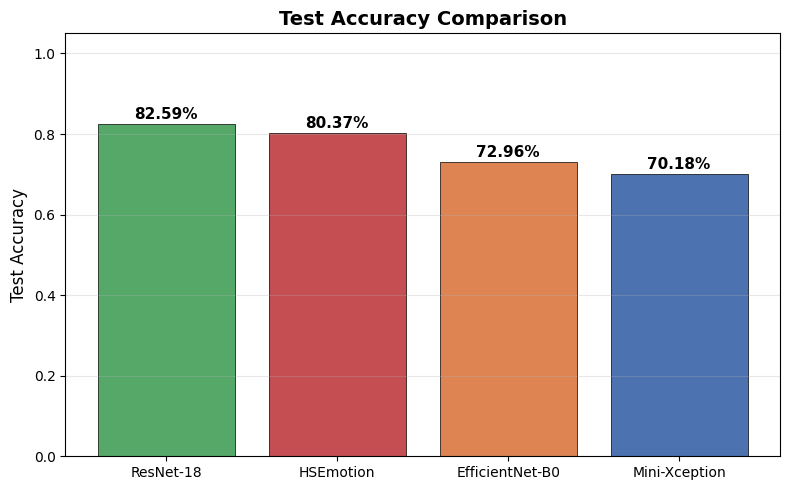

In [110]:
fig, ax = plt.subplots(figsize=(8, 5))

models = df_comparison["Model"].tolist()
accuracies = df_comparison["Accuracy"].tolist()
colors = [MODEL_COLORS.get(m, "#999999") for m in models]

bars = ax.bar(
    models, accuracies,
    color=colors, edgecolor="black", linewidth=0.5,
)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{acc:.2%}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
    )

ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title(
    "Test Accuracy Comparison",
    fontsize=14, fontweight="bold",
)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "accuracy_comparison.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## 11. Per-Class F1-Score Comparison

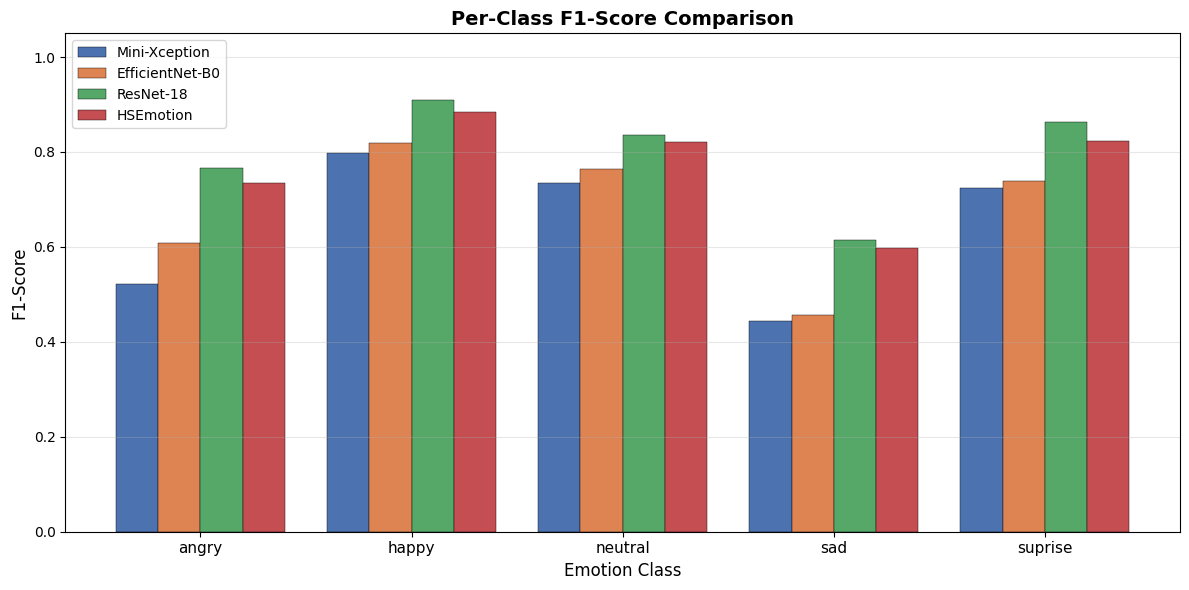

In [118]:
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(evaluation_results.keys())
n_models = len(model_names)
n_classes = len(CLASS_NAMES)
x = np.arange(n_classes)
width = 0.8 / n_models

for i, model_name in enumerate(model_names):
    report = evaluation_results[model_name]["report"]
    f1_scores = [report[cls]["f1-score"] for cls in CLASS_NAMES]
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(
        x + offset, f1_scores, width,
        label=model_name,
        color=MODEL_COLORS.get(model_name, "#999999"),
        edgecolor="black", linewidth=0.3,
    )

ax.set_xlabel("Emotion Class", fontsize=12)
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_title(
    "Per-Class F1-Score Comparison",
    fontsize=14, fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "f1_per_class.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## 12. Precision and Recall Comparison

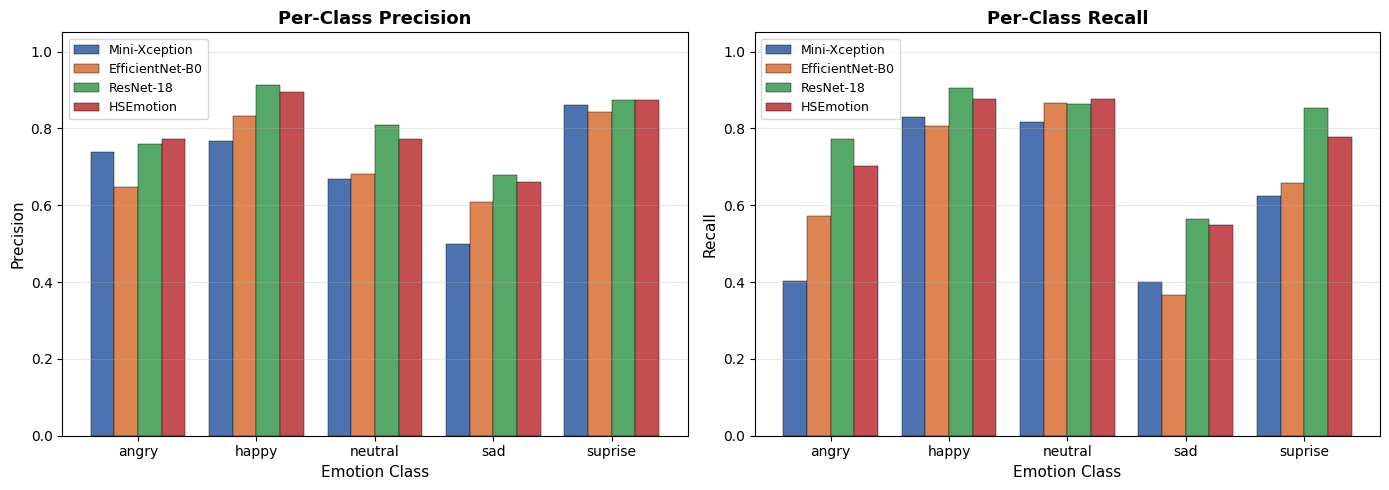

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_keys = [("precision", "Precision"), ("recall", "Recall")]

for ax, (metric_key, metric_label) in zip(axes, metric_keys):
    for i, model_name in enumerate(model_names):
        report = evaluation_results[model_name]["report"]
        values = [
            report[cls][metric_key] for cls in CLASS_NAMES
        ]
        offset = (i - n_models / 2 + 0.5) * width
        ax.bar(
            x + offset, values, width,
            label=model_name,
            color=MODEL_COLORS.get(model_name, "#999999"),
            edgecolor="black", linewidth=0.3,
        )
    ax.set_xlabel("Emotion Class", fontsize=11)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(
        f"Per-Class {metric_label}",
        fontsize=13, fontweight="bold",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "precision_recall_comparison.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## 13. Confusion Matrices

Normalized confusion matrices for each model, showing per-class recall
(diagonal) and common misclassification patterns (off-diagonal).

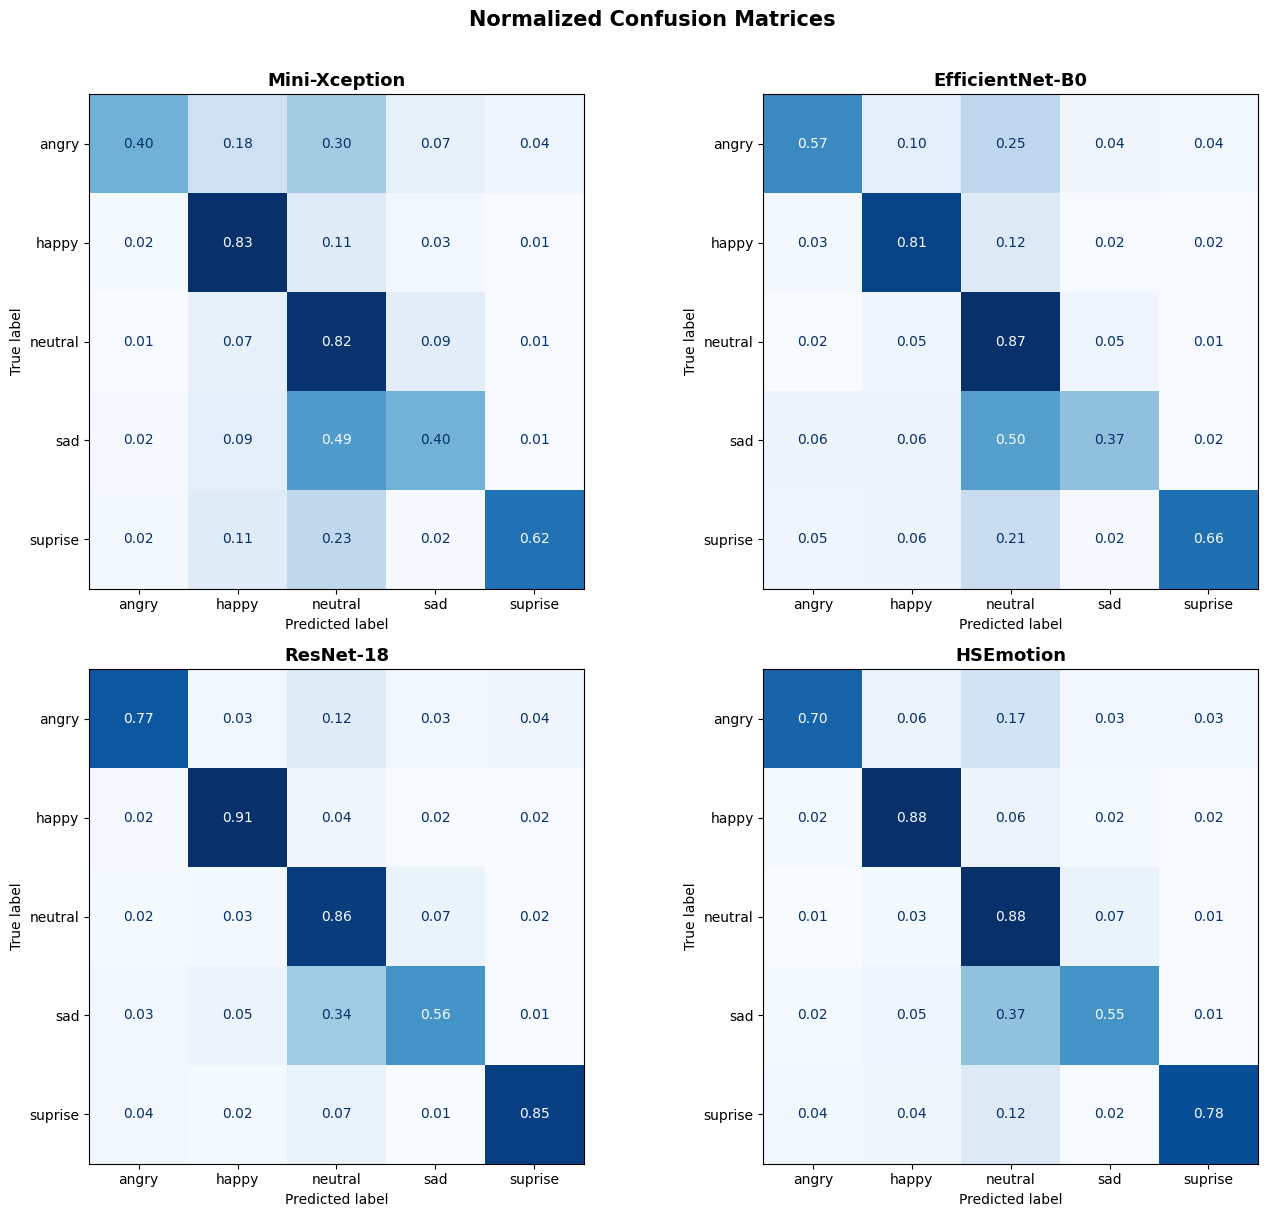

In [113]:
n_evaluated = len(evaluation_results)
n_cols = min(n_evaluated, 2)
n_rows = (n_evaluated + n_cols - 1) // n_cols
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, 6 * n_rows),
)

# Ensure axes is always a flat iterable
if n_evaluated == 1:
    axes_flat = [axes]
else:
    axes_flat = axes.flatten()

for idx, (model_name, result) in enumerate(
    evaluation_results.items()
):
    ax = axes_flat[idx]
    cm = confusion_matrix(
        result["y_true"], result["y_pred"],
        labels=list(range(NUM_CLASSES)),
        normalize="true",
    )
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=CLASS_NAMES,
    )
    disp.plot(
        ax=ax, cmap="Blues",
        colorbar=False, values_format=".2f",
    )
    ax.set_title(model_name, fontsize=13, fontweight="bold")

# Hide unused axes
for idx in range(n_evaluated, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(
    "Normalized Confusion Matrices",
    fontsize=15, fontweight="bold", y=1.01,
)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "confusion_matrices.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## 14. Training History Comparison

Overlay the training and validation curves from all models to compare
convergence speed, overfitting behavior, and final performance. These
curves are loaded from the JSON history files saved by each training
notebook.

**Note:** Mini-Xception was trained from scratch (single phase, 30
epochs). EfficientNet-B0, ResNet-18, and HSEmotion were trained with a
two-phase approach; the histories shown here are from Phase 2
(partial fine-tuning, 30 epochs).

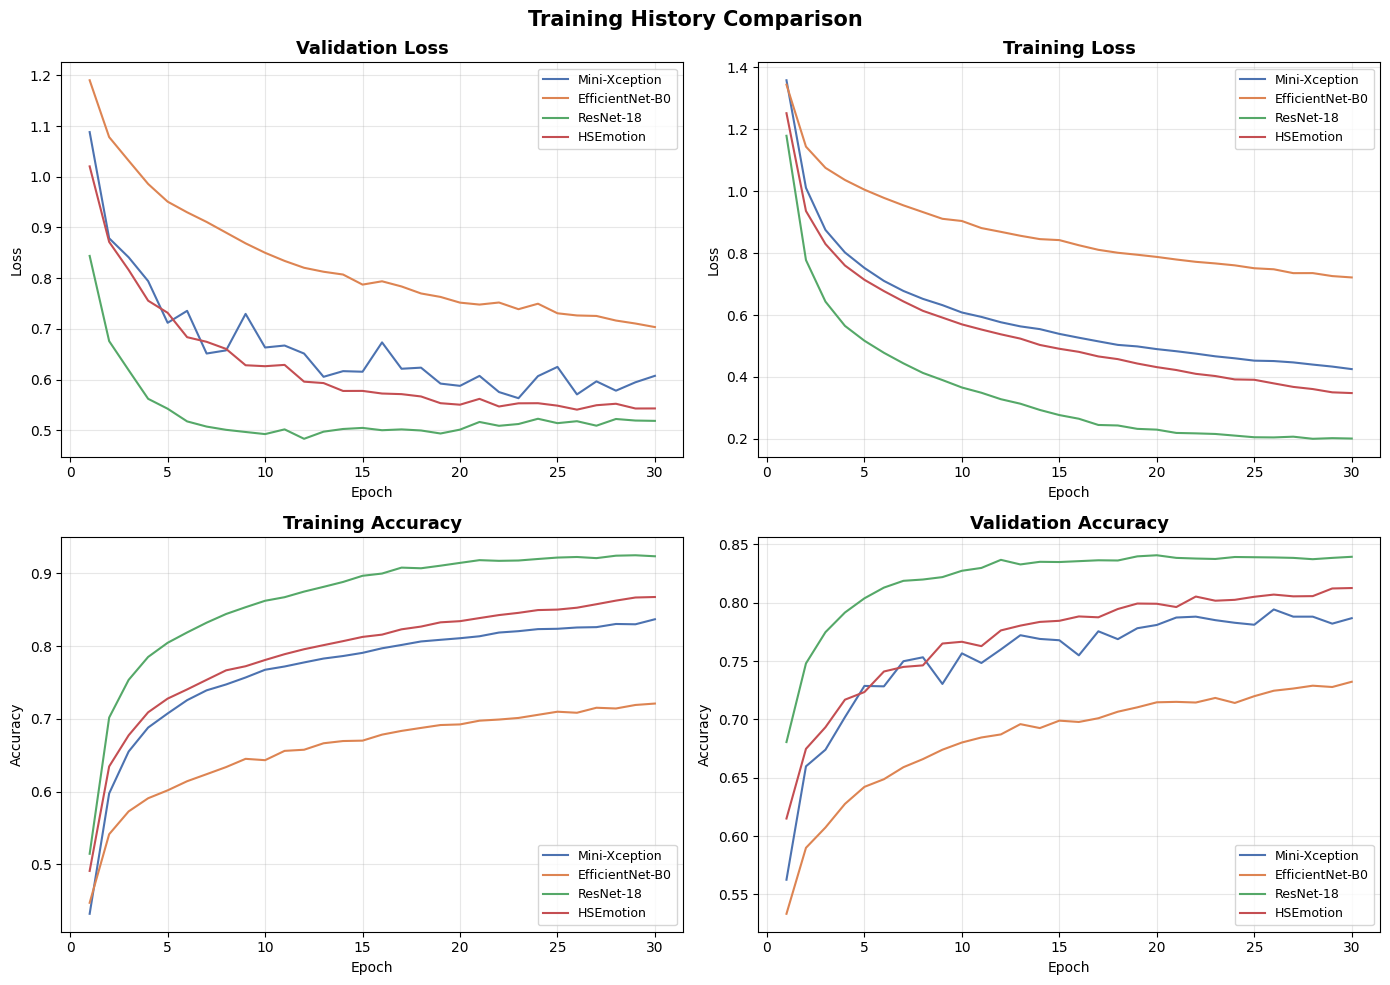

In [119]:
# Collect available training histories
histories = {}
for display_name, data in json_results.items():
    if data["history"] is not None:
        histories[display_name] = data["history"]

if not histories:
    print("No training history JSON files available.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Top-left: Training Loss
    ax = axes[0, 1]
    for name, hist in histories.items():
        epochs = range(1, len(hist["train_loss"]) + 1)
        ax.plot(
            epochs, hist["train_loss"],
            label=name, color=MODEL_COLORS.get(name),
            linewidth=1.5,
        )
    ax.set_title("Training Loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Top-right: Validation Loss
    ax = axes[0, 0]
    for name, hist in histories.items():
        epochs = range(1, len(hist["val_loss"]) + 1)
        ax.plot(
            epochs, hist["val_loss"],
            label=name, color=MODEL_COLORS.get(name),
            linewidth=1.5,
        )
    ax.set_title(
        "Validation Loss", fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Bottom-left: Training Accuracy
    ax = axes[1, 0]
    for name, hist in histories.items():
        epochs = range(1, len(hist["train_acc"]) + 1)
        ax.plot(
            epochs, hist["train_acc"],
            label=name, color=MODEL_COLORS.get(name),
            linewidth=1.5,
        )
    ax.set_title(
        "Training Accuracy", fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Bottom-right: Validation Accuracy
    ax = axes[1, 1]
    for name, hist in histories.items():
        epochs = range(1, len(hist["val_acc"]) + 1)
        ax.plot(
            epochs, hist["val_acc"],
            label=name, color=MODEL_COLORS.get(name),
            linewidth=1.5,
        )
    ax.set_title(
        "Validation Accuracy",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    fig.suptitle(
        "Training History Comparison",
        fontsize=15, fontweight="bold",
    )
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / "training_history.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()

## 15. Parameter Efficiency Analysis

Compare model size (trainable parameters) against test accuracy.
A model in the upper-left region of the scatter plot achieves high
accuracy with fewer parameters, indicating better efficiency.

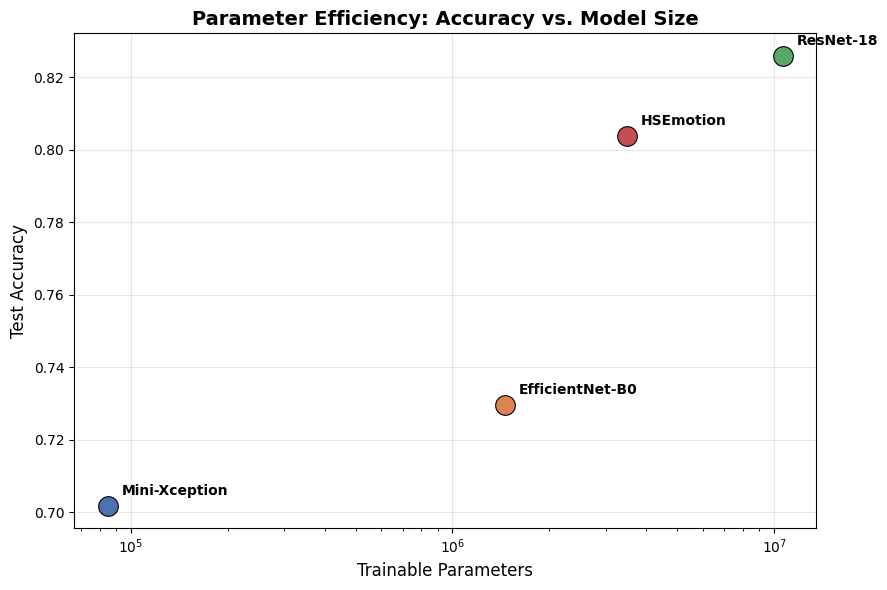


Parameter Summary:


,Model,Total Params,Trainable Params,Test Accuracy
0,Mini-Xception,"84,741","84,741",0.7018
1,EfficientNet-B0,"4,336,769","1,458,613",0.7296
2,ResNet-18,"11,309,125","10,626,053",0.8259
3,HSEmotion,"4,336,769","3,484,961",0.8037


In [115]:
# Build parameter data
param_rows = []
for display_name, result in evaluation_results.items():
    param_rows.append({
        "Model": display_name,
        "Total Params": result["total_params"],
        "Trainable Params": result["trainable_params"],
        "Test Accuracy": result["report"]["accuracy"],
    })

df_params = pd.DataFrame(param_rows)

# Scatter plot: params vs accuracy
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in df_params.iterrows():
    name = row["Model"]
    ax.scatter(
        row["Trainable Params"],
        row["Test Accuracy"],
        s=200,
        color=MODEL_COLORS.get(name, "#999999"),
        edgecolors="black", linewidth=0.8, zorder=5,
    )
    ax.annotate(
        name,
        (row["Trainable Params"], row["Test Accuracy"]),
        textcoords="offset points", xytext=(10, 8),
        fontsize=10, fontweight="bold",
    )

ax.set_xlabel("Trainable Parameters", fontsize=12)
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title(
    "Parameter Efficiency: Accuracy vs. Model Size",
    fontsize=14, fontweight="bold",
)
ax.set_xscale("log")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "parameter_efficiency.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

# Parameter summary table
print("\nParameter Summary:")
display(df_params.style.format({
    "Total Params": "{:,.0f}",
    "Trainable Params": "{:,.0f}",
    "Test Accuracy": "{:.4f}",
}))

## 16. Save Comparison Outputs

In [116]:
# List all saved artifacts
print(f"Comparison artifacts saved to: {OUTPUT_DIR}")
print("-" * 60)
for f in sorted(OUTPUT_DIR.iterdir()):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name:<45s} {size_kb:>8.1f} KB")

Comparison artifacts saved to: /content/adaptive-emotion-aware-virtual-interaction-system/results/model_comparison
------------------------------------------------------------
  accuracy_comparison.png                           43.3 KB
  confusion_matrices.png                           172.3 KB
  f1_per_class.png                                  49.4 KB
  metrics_summary.csv                                0.6 KB
  parameter_efficiency.png                          53.4 KB
  per_class_metrics.csv                              1.6 KB
  precision_recall_comparison.png                   50.0 KB
  training_history.png                             280.3 KB


In [117]:
if SAVE_TO_DRIVE:
    drive_dir = Path(DRIVE_OUTPUT_DIR)
    drive_dir.mkdir(parents=True, exist_ok=True)
    for f in OUTPUT_DIR.iterdir():
        if f.is_file():
            shutil.copy2(f, drive_dir / f.name)
    n_files = len([
        f for f in OUTPUT_DIR.iterdir() if f.is_file()
    ])
    print(f"Copied {n_files} files to {drive_dir}")
else:
    print(
        "Drive saving disabled. "
        "Set SAVE_TO_DRIVE = True to copy outputs."
    )

Copied 8 files to /content/drive/MyDrive/Lisans/Classe 4/Bitirme/results/model_comparison


## 17. Summary and Interpretation

### Key Findings

The table below recaps the models ranked by test accuracy:

| Rank | Model | Test Accuracy | Macro F1 | Trainable Params |
|------|-------|--------------|----------|------------------|
| 1 | ResNet-18 | ~82.6% | ~0.80 | ~10.6M |
| 2 | HSEmotion | ~80.3% | ~0.77 | ~3.5M |
| 3 | Mini-Xception | ~77.2% | ~0.74 | ~85K |
| 4 | EfficientNet-B0 | ~72.9% | ~0.68 | ~1.5M |

### Observations

1. **ResNet-18 achieves the highest test accuracy** among all four models.
   Its larger capacity (10.6M trainable parameters in Phase 2) allows it to
   learn richer feature representations from the partially unfrozen backbone.

2. **HSEmotion ranks second** despite having fewer trainable parameters than
   ResNet-18. The AffectNet-pretrained backbone provides domain-relevant
   features that partially compensate for the smaller fine-tuning budget.

3. **Mini-Xception offers the best parameter efficiency.** With only ~85K
   parameters (trained from scratch, no pretraining), it achieves 77.2%
   accuracy -- only 5.4 percentage points below ResNet-18.

4. **EfficientNet-B0 underperforms relative to its size.** Despite ~1.5M
   trainable parameters and ImageNet pretraining, it ranks last. This may
   reflect suboptimal hyperparameters or the fact that fewer backbone layers
   were unfrozen compared to ResNet-18.

5. **The "sad" emotion is consistently the hardest class** for all models,
   with the lowest F1-scores. This likely results from visual overlap with
   "neutral" expressions and class imbalance in the FERPlus dataset.

6. **"Happy" is the easiest class** across all architectures, consistently
   achieving F1-scores above 0.80. This aligns with the general finding
   that happiness has the most distinctive facial features.

### Limitations

- Mini-Xception uses 64x64 input resolution; all other models use 224x224.
  This resolution difference means the preprocessing is not fully identical,
  though the normalization scheme is the same.
- The comparison uses Phase 2 (fine-tuned) checkpoints for transfer learning
  models. Phase 1 (frozen backbone) results are shown in the JSON summary
  table but not in the direct evaluation.
- The "suprise" class name typo in the FERPlus dataset folder is preserved
  throughout to maintain consistency with the saved checkpoints and results.
- Parameter counts for training are taken from the JSON evaluation summaries
  (which reflect the fine-tuning setup). The total parameter counts shown in
  the efficiency analysis are computed from the loaded models.